In [1]:
%load_ext autoreload
# %reload_ext autoreload
%autoreload 1

%aimport b6_epilepsies 
import b6_epilepsies as b6 #.py file in the same dir as this .ipynb
from b6_epilepsies_func import *
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Define input variables
date   = "250314"
box1   = "14"
box2   = "15"
exp    = "PLPBP_paradigm"
export = False

# omit = {box1:['H7','D8','D9','D12']}
    
para_obj_raw = b6.RawData(date, box1, box2, exp, export) #.prepped_data attribute to access df

# ald_lys_obj_mid  = b6.MiddurData(date, box1, box2, exp, export, omit=omit) #.prepped_data attribute to access df
df_raw = para_obj_raw.df
# all_seizure_df = plpbp_para_obj_raw.generate_all_seizure_df()

Initialising RawData...
Start of experiment: 2025-03-14 18:22:37
Instantiated using 250314_14_15_PLPBP_paradigm/250314_14_15_PLPBP_paradigm_processed.csv, no need to prepare raw data.
Done.


Testing 1/56: min_duration=20, min_ibi=1
Testing 2/56: min_duration=20, min_ibi=3
Testing 3/56: min_duration=20, min_ibi=5
Testing 4/56: min_duration=20, min_ibi=7
Testing 5/56: min_duration=20, min_ibi=9
Testing 6/56: min_duration=20, min_ibi=11
Testing 7/56: min_duration=20, min_ibi=13
Testing 8/56: min_duration=20, min_ibi=15
Testing 9/56: min_duration=25, min_ibi=1
Testing 10/56: min_duration=25, min_ibi=3
Testing 11/56: min_duration=25, min_ibi=5
Testing 12/56: min_duration=25, min_ibi=7
Testing 13/56: min_duration=25, min_ibi=9
Testing 14/56: min_duration=25, min_ibi=11
Testing 15/56: min_duration=25, min_ibi=13
Testing 16/56: min_duration=25, min_ibi=15
Testing 17/56: min_duration=30, min_ibi=1
Testing 18/56: min_duration=30, min_ibi=3
Testing 19/56: min_duration=30, min_ibi=5
Testing 20/56: min_duration=30, min_ibi=7
Testing 21/56: min_duration=30, min_ibi=9
Testing 22/56: min_duration=30, min_ibi=11
Testing 23/56: min_duration=30, min_ibi=13
Testing 24/56: min_duration=30, min

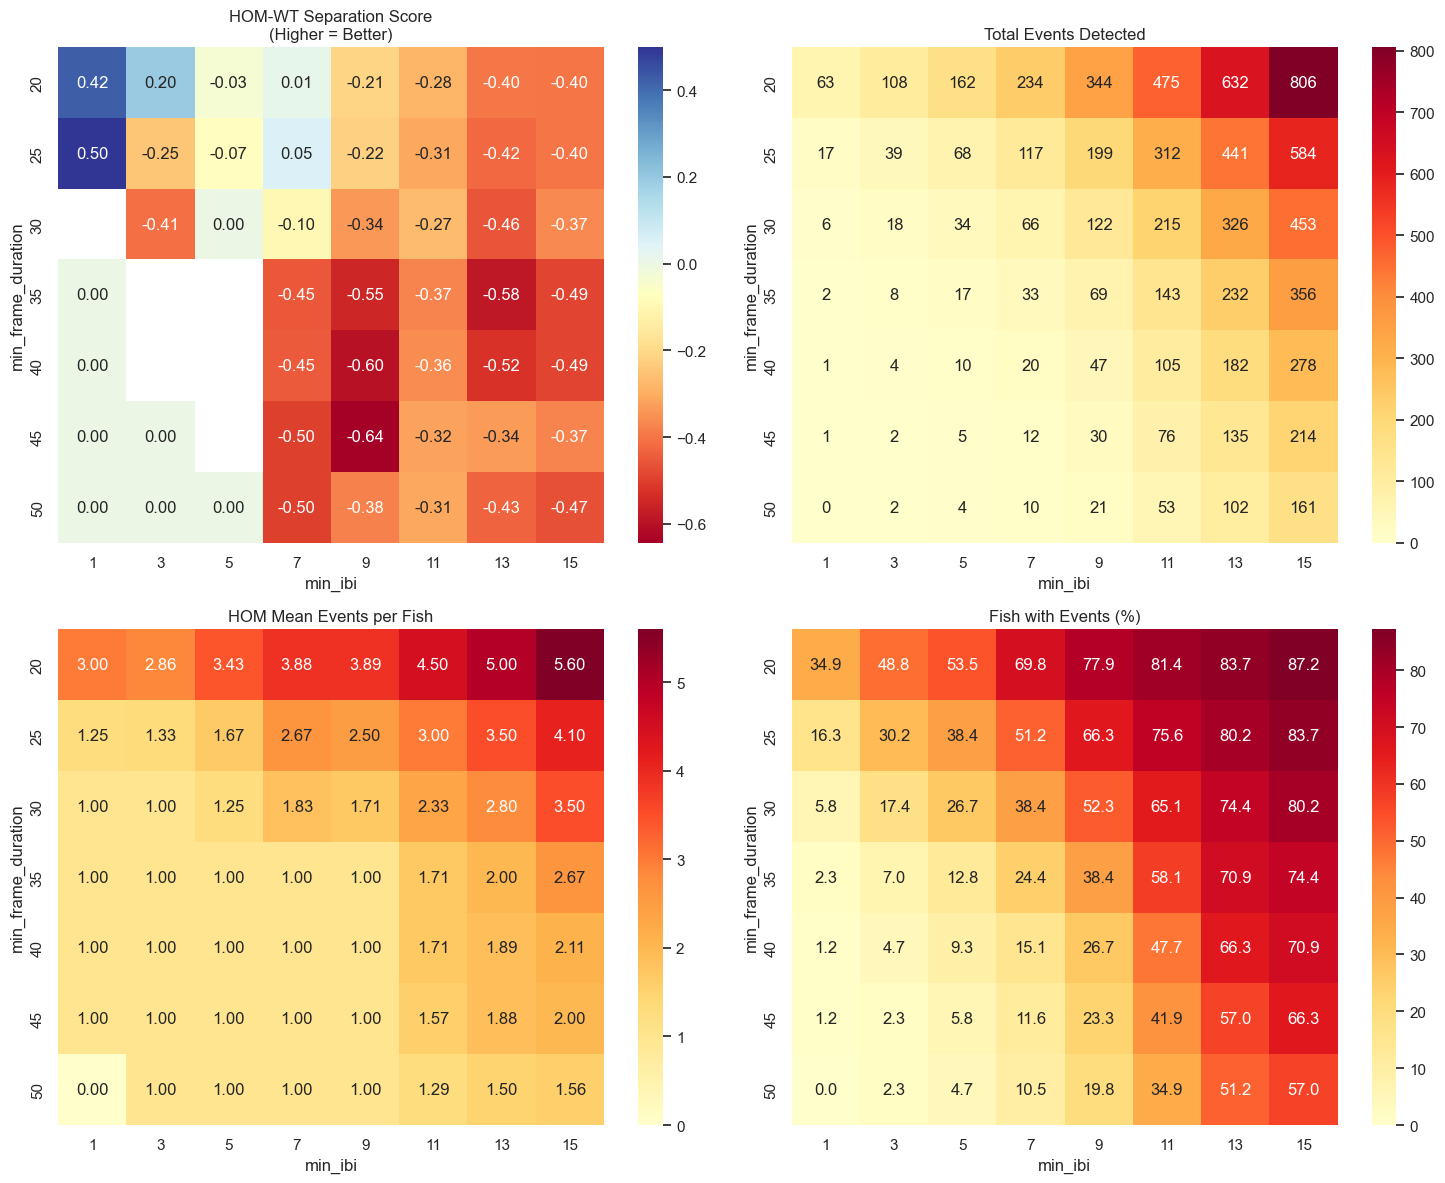

In [3]:
# segment = segment_dfs['seg_spont']
segment = df_raw[(df_raw['elapsed_time'] >= 0) & (df_raw['elapsed_time'] <= 60)]

# Run the parameter sweep
sweep_results = sweep_seizure_parameters_detailed(
    detect_seizures_func=para_obj_raw.detect_seizures,  # function
    raw_data_df=segment,
    param_ranges={
        'min_frame_duration_range': range(20, 51, 5),    # 10 to 50 frames
        'min_ibi_range': range(1, 16, 2)                 # 1 to 15 frames
    }
)

# Find optimal parameters
optimal_params = find_optimal_parameters_standalone(sweep_results, para_obj_raw.name)

# Now you can use these optimal parameters manually
print(f"\nUse these parameters in your analysis:")
print(f"min_frame_duration = {optimal_params['min_frame_duration']}")
print(f"min_ibi = {optimal_params['min_ibi']}")

# Plot results
plot_parameter_sweep_standalone(sweep_results)

In [16]:
obj = plpbp_para_obj_raw

seg_spontaneous   = df_raw[(df_raw['elapsed_time']>= 0) & (df_raw['elapsed_time']<= 60)]
all_seizure_df_s  = obj.generate_all_seizure_df(data=seg_spontaneous)

seg_lightstim     = df_raw[(df_raw['elapsed_time']> 60) & (df_raw['elapsed_time']<= 75)]
all_seizure_df_ls = obj.generate_all_seizure_df(data=seg_lightstim)

seg_drug          = df_raw[df_raw['elapsed_time']> 80]
all_seizure_df_d  = obj.generate_all_seizure_df(data=seg_drug)


Generating all_seizure_df...
Done
Generating all_seizure_df...
Done
Generating all_seizure_df...
Done


In [30]:
summary_stats = (
    all_seizure_df_s
    .sort_values('genotype', key=lambda x: x.map({g: i for i, g in enumerate(genotype_order)}))
    .groupby('genotype', sort=False)[['duration', 'IBI']]
    .agg(['count', 'mean', 'std', 'max'])
)

summary_stats

duration                             IBI                           \
            count       mean        std max count        mean          std   
genotype                                                                     
WT             14  31.214286   5.101713  45    14   28.357143    23.503215   
HET            17  31.941176   8.143023  55    17  528.117647  2001.719913   
HOM             8  36.000000  16.440368  76     8  143.875000   159.366099   

                
           max  
genotype        
WT          88  
HET       8292  
HOM        396

In [29]:
summary_stats = (
    all_seizure_df_ls
    .sort_values('genotype', key=lambda x: x.map({g: i for i, g in enumerate(genotype_order)}))
    .groupby('genotype', sort=False)[['duration', 'IBI']]
    .agg(['count', 'mean', 'std', 'max'])
)

summary_stats

duration                             IBI                            \
            count       mean        std max count         mean          std   
genotype                                                                      
WT              7  37.714286  22.096110  87     7  2708.857143  6622.169066   
HET            17  36.294118  13.066009  72    17   116.411765   353.591052   
HOM             1  26.000000        NaN  26     1     9.000000          NaN   
Excluded        1  43.000000        NaN  43     1  1457.000000          NaN   

                 
            max  
genotype         
WT        17700  
HET        1461  
HOM           9  
Excluded   1457

In [28]:
summary_stats = (
    all_seizure_df_d
    .sort_values('genotype', key=lambda x: x.map({g: i for i, g in enumerate(genotype_order)}))
    .groupby('genotype', sort=False)[['duration', 'IBI']]
    .agg(['count', 'mean', 'std', 'max'])
)

summary_stats

duration                              IBI                           \
            count       mean        std  max count        mean          std   
genotype                                                                      
WT            136  39.985294  20.718210  207   136  238.411765  1522.065626   
HET           136  40.007353  17.098190  130   136  624.272059  4736.648796   
HOM            22  32.545455   8.770770   63    22  137.863636   166.255768   
Excluded        2  29.000000   2.828427   31     2   17.500000     2.121320   

                 
            max  
genotype         
WT        13422  
HET       54490  
HOM         641  
Excluded     19

Seizure Duration Data Normal? False
Seizure Count Data Normal? False

Seizure Duration Test Used: Kruskal-Wallis | p = 0.0718
WT vs HET: p = 0.8651
WT vs HOM: p = 0.0216
HET vs HOM: p = 0.0351

Seizure Count Test Used: Kruskal-Wallis | p = 0.0036
WT vs HET: p = 0.0410
WT vs HOM: p = 0.0636
HET vs HOM: p = 0.0014
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

WT vs. HET: Custom statistical test, P_val:8.651e-01
HET vs. HOM: Custom statistical test, P_val:3.513e-02
WT vs. HOM: Custom statistical test, P_val:2.163e-02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

WT vs. HET: Custom statistical test, P_val:4.102e-02
HET vs. HOM: Custom statistical test, P_val:1.439e-03
WT vs. HOM: Custom statistical test

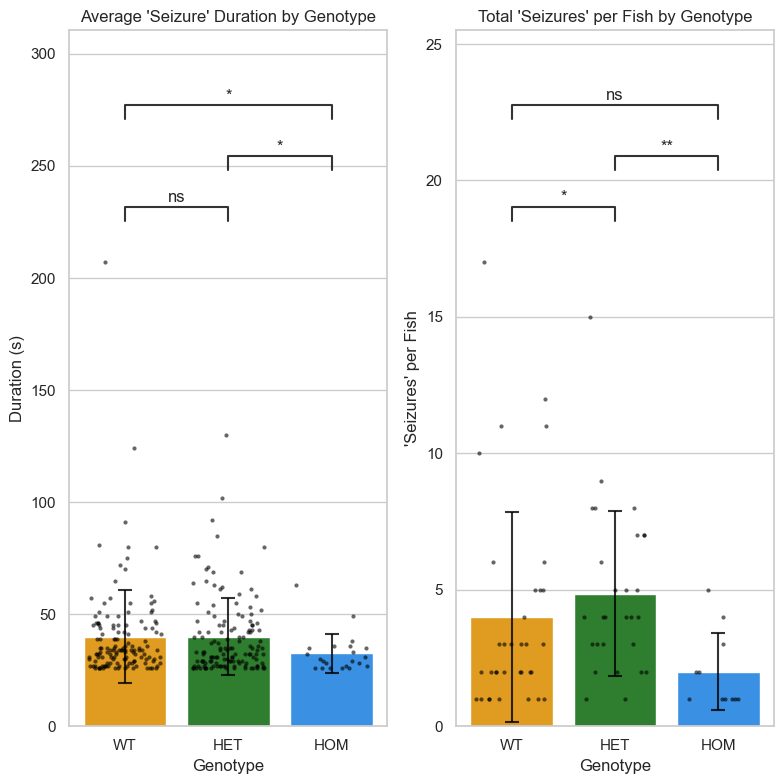

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, normaltest, kruskal, mannwhitneyu, f_oneway, ttest_ind
from statannotations.Annotator import Annotator

# all_seizure_df = all_seizure_df_s
# all_seizure_df = all_seizure_df_ls
all_seizure_df = all_seizure_df_d

# Define genotype order and colors
genotype_order = ["WT", "HET", "HOM"]
genotype_colors = {"WT": "#FFA500", "HET": "#228B22", "HOM": "#1E90FF"}

# Ensure genotype is categorical
all_seizure_df['genotype'] = pd.Categorical(all_seizure_df['genotype'], categories=genotype_order, ordered=True)

# Step 1: Count seizures per fish (group by `box`, `well`)
seizure_counts_per_fish = all_seizure_df.groupby(["box", "well"]).size().reset_index(name="seizure_count")

# Step 2: Extract genotype for each fish (keep only first occurrence)
genotype_mapping = all_seizure_df.groupby(["box", "well"])["genotype"].first().reset_index()

# Step 3: Merge genotype back
seizure_counts_per_fish = seizure_counts_per_fish.merge(genotype_mapping, on=["box", "well"], how="left")

# Step 4: Compute summary statistics per genotype
genotype_stats = all_seizure_df.groupby(['genotype'], observed=False).agg(
    duration_mean=('duration', 'mean'),
    duration_std=('duration', 'std'),
    interbout_mean=('IBI', 'mean'),
    interbout_std=('IBI', 'std')
).reset_index()

# Fix: Group seizure_counts_per_fish by genotype, not well
genotype_stats_seizure_count = seizure_counts_per_fish.groupby(['genotype'], observed=False).agg(
    seizure_count_mean=('seizure_count', 'mean'),
    seizure_count_std=('seizure_count', 'std')
).reset_index()

# **Sort for proper ordering**
genotype_stats = genotype_stats.sort_values(by=['genotype'])
genotype_stats_seizure_count = genotype_stats_seizure_count.sort_values(by=['genotype'])


# **Step 5: Normality Tests**
normality_results = {}

for measure, data_source in [("duration", all_seizure_df), ("seizure_count", seizure_counts_per_fish)]:
    normality_results[measure] = {}
    
    for genotype in genotype_order:
        data = data_source.loc[data_source['genotype'] == genotype, measure]
        n = len(data)
        
        if n > 3:  # Ensure at least 3 values before running normality test
            shapiro_p = shapiro(data).pvalue
            dagostino_p = normaltest(data).pvalue if n >= 20 else None  # Skip `normaltest()` if n < 20
            
            normality_results[measure][genotype] = {
                "Shapiro-Wilk p": shapiro_p,
                "D’Agostino-Pearson p": dagostino_p
            }
        else:
            normality_results[measure][genotype] = {
                "Shapiro-Wilk p": None,
                "D’Agostino-Pearson p": None
            }


# Function to determine normality

def is_normal(p_values):
    skipped_groups = [g for g, p in p_values.items() if p is None]

    if skipped_groups:
        print(f"Skipping normality test for: {', '.join(skipped_groups)} (too few data points)")

    return all(p is not None and p >= 0.05 for p in p_values.values() if p is not None)

# Check normality
is_duration_normal = is_normal({g: normality_results["duration"][g]["Shapiro-Wilk p"] for g in genotype_order})
is_seizure_count_normal = is_normal({g: normality_results["seizure_count"][g]["Shapiro-Wilk p"] for g in genotype_order})

print(f"Seizure Duration Data Normal? {is_duration_normal}")
print(f"Seizure Count Data Normal? {is_seizure_count_normal}")

# **Step 6: Statistical Tests**
def run_statistical_tests(data, measure, is_normal):
    valid_groups = [g for g in genotype_order if g in data['genotype'].unique()]

    if len(valid_groups) < 2:
        print(f"⚠️ Not enough valid genotype groups for {measure} comparison. Skipping statistical tests.")
        return None, None, {}

    if is_normal:
        overall_p = f_oneway(*[data.loc[data['genotype'] == g, measure] for g in valid_groups]).pvalue
        test_name = "ANOVA"
        pairwise_tests = {
            pair: ttest_ind(
                data.loc[data['genotype'] == pair[0], measure],
                data.loc[data['genotype'] == pair[1], measure]
            ).pvalue
            for pair in pairwise_comparisons if pair[0] in valid_groups and pair[1] in valid_groups
        }
    else:
        overall_p = kruskal(*[data.loc[data['genotype'] == g, measure] for g in valid_groups]).pvalue
        test_name = "Kruskal-Wallis"
        pairwise_tests = {
            pair: mannwhitneyu(
                data.loc[data['genotype'] == pair[0], measure],
                data.loc[data['genotype'] == pair[1], measure]
            ).pvalue
            for pair in pairwise_comparisons if pair[0] in valid_groups and pair[1] in valid_groups
        }

    return test_name, overall_p, pairwise_tests
    
pairwise_comparisons = [("WT", "HET"), ("WT", "HOM"), ("HET", "HOM")]

def plot_with_points_and_error(ax, data, stats, y_col, y, std_col, y_label, title, p_values):
    # Ensure all genotypes are included by reindexing with full genotype order
    stats = stats.set_index("genotype").reindex(genotype_order).reset_index()
    
    # Fill NaN values with 0 (so missing genotypes still appear)
    stats.fillna({y_col: 0, std_col: 0}, inplace=True)

    sns.barplot(
        data=stats,
        x="genotype",
        y=y_col,
        errorbar=None,
        order=genotype_order, 
        ax=ax,
        hue="genotype",
        palette=genotype_colors,  
        legend=False  
    )
    sns.stripplot(
        data=data,
        x="genotype",
        y=y,
        dodge=False,
        jitter=0.35,
        order=genotype_order, ax=ax, color='black', alpha=0.6, size=3
    )
    ax.errorbar(
        stats["genotype"], stats[y_col], yerr=stats[std_col],
        fmt='none', ecolor='black', capsize=5, capthick=1.5, alpha=0.8
    )

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Genotype', fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)
    ax.set_ylim(0, data[y].max() * 1.5 if not data[y].isna().all() else 1)  # Prevents scaling errors if all values are NaN

    # Only annotate if valid p-values exist
    if p_values:
        pairs = [("WT", "HET"), ("WT", "HOM"), ("HET", "HOM")]
        annotator = Annotator(ax, pairs, data=data, x="genotype", y=y, order=genotype_order)
        annotator.configure(test=None, text_format="star", loc="inside")
        annotator.set_pvalues_and_annotate([p_values.get(pair, 1) for pair in pairs])
    else:
        print(f"⚠️ Skipping annotation for {title}: Not enough valid data.")

# # **Plot 1: Seizure Duration**
# plot_with_points_and_error(
#     axes[0], all_seizure_df, genotype_stats, 
#     "duration_mean", "duration", "duration_std", 
#     "Duration (s)", "Average 'Seizure' Duration by Genotype", 
#     duration_pairwise_tests
# )

# # **Plot 2: Seizure Count per Fish**
# plot_with_points_and_error(
#     axes[1], seizure_counts_per_fish, genotype_stats_seizure_count, 
#     "seizure_count_mean", "seizure_count", "seizure_count_std", 
#     "'Seizures' per Fish", "Total 'Seizures' per Fish by Genotype", 
#     seizure_count_pairwise_tests
# )


# Run statistical tests
duration_test_name, duration_p, duration_pairwise_tests = run_statistical_tests(
    all_seizure_df, "duration", is_duration_normal
)
seizure_count_test_name, seizure_count_p, seizure_count_pairwise_tests = run_statistical_tests(
    seizure_counts_per_fish, "seizure_count", is_seizure_count_normal
)

# Prevent annotation if no valid tests
if not duration_pairwise_tests:
    print("⚠️ Skipping annotation for duration: Not enough valid comparisons.")
else:
    # Print results
    print(f"\nSeizure Duration Test Used: {duration_test_name} | p = {duration_p:.4f}")
    for pair, p_val in duration_pairwise_tests.items():
        print(f"{pair[0]} vs {pair[1]}: p = {p_val:.4f}")

if not seizure_count_pairwise_tests:
    print("⚠️ Skipping annotation for seizure count: Not enough valid comparisons.")
else:
    print(f"\nSeizure Count Test Used: {seizure_count_test_name} | p = {seizure_count_p:.4f}")
    for pair, p_val in seizure_count_pairwise_tests.items():
        print(f"{pair[0]} vs {pair[1]}: p = {p_val:.4f}")
    

# Print results
# print(f"\nSeizure Duration Test Used: {duration_test_name} | p = {duration_p:.4f}")
# for pair, p_val in duration_pairwise_tests.items():
#     print(f"{pair[0]} vs {pair[1]}: p = {p_val:.4f}")

# print(f"\nSeizure Count Test Used: {seizure_count_test_name} | p = {seizure_count_p:.4f}")
# for pair, p_val in seizure_count_pairwise_tests.items():
#     print(f"{pair[0]} vs {pair[1]}: p = {p_val:.4f}")


# Always plot, even if statistical tests are missing
fig, axes = plt.subplots(1, 2, figsize=(8, 8))

# **Plot 1: Seizure Duration**
plot_with_points_and_error(
    axes[0], all_seizure_df, genotype_stats, 
    "duration_mean", "duration", "duration_std", 
    "Duration (s)", "Average 'Seizure' Duration by Genotype", 
    duration_pairwise_tests
)

# **Plot 2: Seizure Count per Fish**
plot_with_points_and_error(
    axes[1], seizure_counts_per_fish, genotype_stats_seizure_count, 
    "seizure_count_mean", "seizure_count", "seizure_count_std", 
    "'Seizures' per Fish", "Total 'Seizures' per Fish by Genotype", 
    seizure_count_pairwise_tests
)

plt.tight_layout()

# Save figure with transparent background
# plt.savefig("250214_14_15_ALDH7A1_20LYS_7dpf.png", dpi=300, bbox_inches='tight', transparent=True)

plt.show()